# Triazole residence time in Lake Geneva for a specific mixing scenario

In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
import xarray as xr
from functions import export_netcdf_xr


# Uncomment for interactive plots:
%matplotlib widget 

### The problem

During the summer of 2025, 1,2,4-triazole has been detected in drinking water from Lake Geneva with concentrations ~0.7 µg/l, which is above the recommended threshold of 0.1 µg/l. The main source of triazole seems to be an industrial site in Monthey that is discharging the contaminant to the Rhône River entering Lake Geneva. The concentration profile below has been taken at the center of the lake (SHL2):

Text(0.5, 0, 'Conc [$\\mu$g/l]')

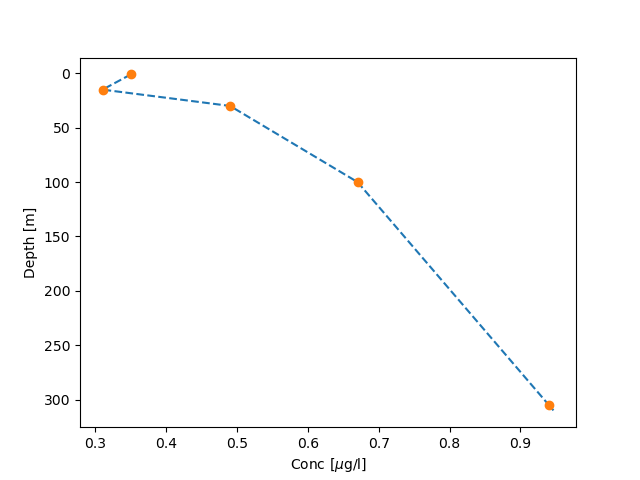

In [32]:
depth=np.array([1,15,30,100,305]) # [m]
conc=np.array([0.35,0.31,0.49,0.67,0.94]) # [ug/l]
C_thresh=0.1

# Add last point assuming a linear increase
depth_bot=310
conc_bot=conc[-1]+(conc[-1]-conc[-2])/(depth[-1]-depth[-2])*(depth_bot-depth[-1])
conc_ext=np.append(conc,conc_bot)
depth_ext=np.append(depth,depth_bot)

depth_interp=np.arange(1,depth_bot+1,1)
conc_interp=np.interp(depth_interp,depth_ext,conc_ext)

plt.figure()
plt.plot(conc_interp,depth_interp,'--')
plt.plot(conc,depth,'o')
plt.gca().invert_yaxis()
plt.gca().set_ylabel("Depth [m]")
plt.gca().set_xlabel("Conc [$\mu$g/l]")

The question we want to answer with this simple model:

*If we stop the input, how long would it take to go back to the recommended concentration of 0.1 µg/l for different mixing scenarios?*

The model applies the following scenarios:
- No mixing between the epilimnion and hypolimnion
- Mixing every $\Delta t$ years (with $\Delta t=1, 5, 10$ years?) 
- Mixing occuring at frequency based on the past probabilistic distribution of mixing events

### The two-box model

We represent Lake Geneva with two boxes: one for the epilimnion with a depth-averaged triazole concentration $C_{epi}$, one for the hypolimnion with a depth-averaged triazole concentration $C_{hypo}$ (see the schematic below). 
The inflow discharge $Q$ is assumed constant over time and equal to the outflow discharge $Q=250\text{ m}^3\text{/s}$. Part of the inflow goes into the epilimnion ($Q_{epi}$), the other part to the hypolimnion ($Q_{hypo}$). The vertical distribution of the inflow is based on estimations from the Rhône density and entrainment over a yearly cycle. No input of triazole is considered ($C_{in}=0$), which means that the Rhône dilutes the triazole concentration in the lake. To fulfill volume conservation, a diffusive mass flux $M_{diff}$ generated by $Q_{hypo}$ is applied from the hypolimnion to the epilimnion.
The volume of the boxes is changing over time according to changes in the epilimion depth $h_{epi}(t)$. Those volume changes mix triazole between the two boxes (mass flux $M_{mix,epi}$ from the hypolimnion to the epilimnion and mass flux $M_{mix,hypo}$ in the opposite direction).

**We assume here that diffusion acts first so that mixing applies to the already diluted layers.**


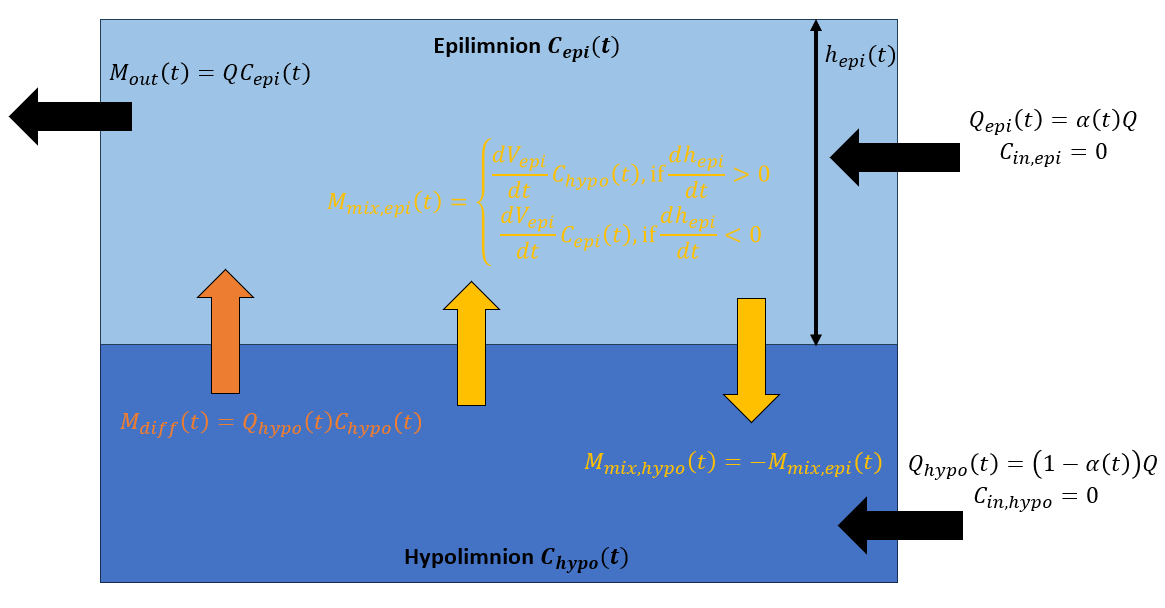

In [33]:
display(Image(filename="Schematic.png",width=800))

### Scenario selection & epilimnion depth time series

Choose the time series of epilimnion depth to use for the residence time calculation.

In [34]:
scenario_names=["constant_scenario","periodic_scenario","simulations"]
scenario_select=2 # 0: constant_scenario, 1: periodic_scenario, 2: simulations

In [35]:
df_hepi=pd.read_csv(os.path.join("Mixing_simulation","lake_geneva_deep_mixing_" + scenario_names[scenario_select] + ".csv"))
hepi=df_hepi.iloc[:,1:].to_numpy() # [m]
dt_yr=1 # [yr], time step (should match the time step used in the simulation)
tyr=np.arange(0,hepi.shape[1],1)*dt_yr # [yr]
dt_sec=dt_yr*365*24*3600 # [s]

### Box volumes

Import lake hypsometry

In [36]:
df_hypso=pd.read_csv(os.path.join("..","..","data","morphology","Lake_Geneva_morphology.csv"))

Computes the volume of the two boxes (epilimnion and hypolimnion) based on the epilimnion depth and the morphology of Lake Geneva. 

In [37]:
Vepi=np.full(hepi.shape,np.nan)
Vhypo=np.full(hepi.shape,np.nan)

for kt in range(len(tyr)):
    Vhypo[:,kt]=np.interp(hepi[:,kt],df_hypso["Depth (m)"],df_hypso["Volume (m3)"]) # [m3]
    Vepi[:,kt]=df_hypso["Volume (m3)"][0]-Vhypo[:,kt] # [m3]

### Inflow

Split the inflow between the epilimnion and the hypolimnion based on the inflow distribution.
Import the plunge depth percentage (i.e., percentage of the time over one year during which the inflow intrudes between the chosen depth and the depth below it).

In [38]:
df_plunge=pd.read_csv(os.path.join("..","..","data","plunge_depth","plunge_depth_percentage.csv"))

Estimate the inflow in each box by assuming that $Q_{epi}$ corresponds to all the inflow in the 20 m-think layer where the epilimnion depth is located summed to the inflows in the layers above. 

In [39]:
Qtot=250 # [m^3/s] Total inflow to Lake Geneva
Qepi=np.full(hepi.shape,np.nan) # [m^3/s]
Qhypo=np.full(hepi.shape,np.nan) # [m^3/s]

for kt in range(len(tyr)):
    for ksim in range(hepi.shape[0]):
        alpha=np.sum(df_plunge["percentage"][:np.where(df_plunge["plunge_depth_m"] < hepi[ksim,kt])[0][-1]])/100 # [-] Fraction of inflow to epilimnion
        Qepi[ksim,kt]=alpha*Qtot
        Qhypo[ksim,kt]=(1-alpha)*Qtot

### Variables initialization

Concentrations:

In [40]:
Cepi=np.full(hepi.shape,np.nan)
Chypo=np.full(hepi.shape,np.nan)

for ksim in range(hepi.shape[0]):
    Cepi[ksim,0]=np.mean(conc_interp[:np.where(depth_interp>=hepi[ksim,0])[0][0]]) # [ug/l]
    Chypo[ksim,0]=np.mean(conc_interp[np.where(depth_interp>=hepi[ksim,0])[0][0]:]) # [ug/l]

Mass fluxes

In [41]:
Mout=np.full(hepi.shape,np.nan) # [mg/s]
Mdiff=np.full(hepi.shape,np.nan) # [mg/s]
Mmix_epi=np.full(hepi.shape,np.nan) # [mg/s]

### Iterations

In [42]:
for kt in range(1,len(tyr)):
    # Outflow from epilimnion
    Mout[:,kt]=Qtot*Cepi[:,kt-1] # [mg/s]

    # First step: diffusion
    Mdiff[:,kt]=Qhypo[:,kt-1]*Chypo[:,kt-1] # [mg/s]
    Cepi_diff=(Cepi[:,kt-1]*Vepi[:,kt-1]+Mdiff[:,kt]*dt_sec-Mout[:,kt]*dt_sec)/Vepi[:,kt-1] # [ug/l]
    Chypo_diff=(Chypo[:,kt-1]*Vhypo[:,kt-1]-Mdiff[:,kt]*dt_sec)/Vhypo[:,kt-1] # [ug/l]

    # Second step: mixing
    for ksim in range(hepi.shape[0]):
        if Vepi[ksim,kt]-Vepi[ksim,kt-1]>0: # If epilimnion volume increases, then water from hypolimnion is mixed into epilimnion
            Mmix_epi[ksim,kt]=(Vepi[ksim,kt]-Vepi[ksim,kt-1])*Chypo_diff[ksim]/dt_sec # [mg/s],>0
        else:
            Mmix_epi[ksim,kt]=(Vepi[ksim,kt]-Vepi[ksim,kt-1])*Cepi_diff[ksim]/dt_sec # [mg/s],<0
    Chypo[:,kt]=(Chypo_diff*Vhypo[:,kt-1]-Mmix_epi[:,kt]*dt_sec)/Vhypo[:,kt] # [ug/l]
    Cepi[:,kt]=(Cepi_diff*Vepi[:,kt-1]+Mmix_epi[:,kt]*dt_sec)/Vepi[:,kt] # [ug/l]

### Save data

In [43]:
ds = xr.Dataset(
    data_vars={
        "hepi": (("simulation", "time"), hepi),
        "Vepi": (("simulation", "time"), Vepi),
        "Vhypo": (("simulation", "time"), Vhypo),
        "Cepi": (("simulation", "time"), Cepi),
        "Chypo": (("simulation", "time"), Chypo),
        "Mout": (("simulation", "time"), Mout),
        "Mdiff": (("simulation", "time"), Mdiff),
        "Mmix_epi": (("simulation", "time"), Mmix_epi),
    },
    coords={
        "simulation": np.arange(Cepi.shape[0]),
        "time": tyr
    }
)

# Add variable attributes
ds["hepi"].attrs = {
    "units": "m",
    "long_name": "Epilimnion depth",
}
ds["Vepi"].attrs = {
    "units": "m3",
    "long_name": "Epilimnion volume",
}
ds["Vhypo"].attrs = {
    "units": "m3",
    "long_name": "Hypolimnion volume",
}

ds["Cepi"].attrs = {
    "units": "ug/L",
    "long_name": "Epilimnion concentration",
}
ds["Chypo"].attrs = {
    "units": "ug/L",
    "long_name": "Hypolimnion concentration",
}
ds["Mout"].attrs = {
    "units": "mg/s",
    "long_name": "Outflow mass flux from epilimnion",
}
ds["Mdiff"].attrs = {
    "units": "mg/s",
    "long_name": "Diffusion mass flux from hypolimnion to epilimnion",
}
ds["Mmix_epi"].attrs = {
    "units": "mg/s",
    "long_name": "Mixing mass flux from hypolimnion to epilimnion",
}


ds.attrs["title"] = "Model results for triazole residence time in Lake Geneva with the scenario: " + scenario_names[scenario_select]

export_netcdf_xr(os.path.join("results", scenario_names[scenario_select] + ".nc"), ds)

Data exported to netCDF!


### Figure

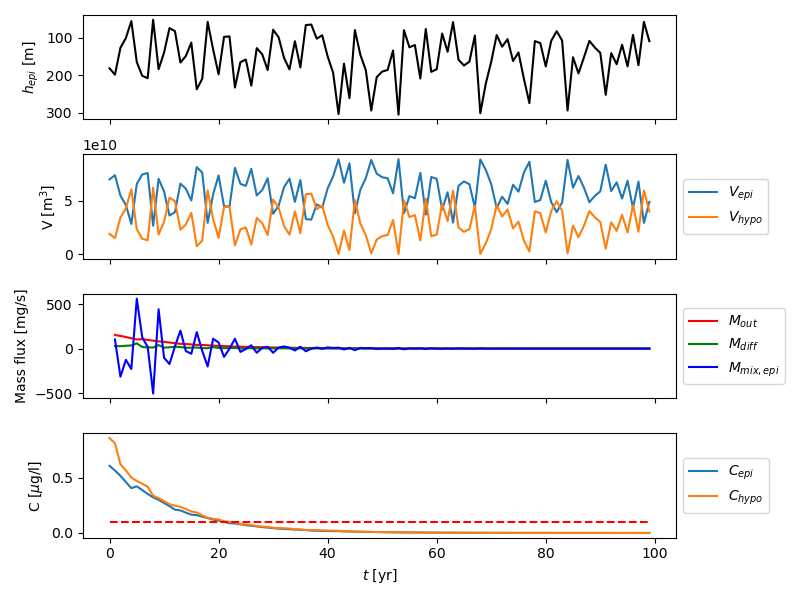

In [44]:
fig,ax=plt.subplots(4,1,figsize=(8,6),sharex=True)

ax[0].plot(tyr,hepi[0,:],'-k',label="$h_{epi}$")
ax[0].set_ylabel("$h_{epi}$ [m]")
ax[0].invert_yaxis()

ax[1].plot(tyr,Vepi[0,:],label="$V_{epi}$")
ax[1].plot(tyr,Vhypo[0,:],label="$V_{hypo}$")
ax[1].set_ylabel("V [m$^3$]")
ax[1].legend(bbox_to_anchor=(1,0.5),loc="center left")

ax[2].plot(tyr,Mout[0,:],'-r',label="$M_{out}$")
ax[2].plot(tyr,Mdiff[0,:],'-g',label="$M_{diff}$")
ax[2].plot(tyr,Mmix_epi[0,:],'-b',label="$M_{mix,epi}$")
ax[2].legend(bbox_to_anchor=(1,0.5),loc="center left")
ax[2].set_ylabel("Mass flux [mg/s]")

ax[3].plot(tyr,Cepi[0,:],label="$C_{epi}$")
ax[3].plot(tyr,Chypo[0,:],label="$C_{hypo}$")
ax[3].plot(tyr[[0,-1]],C_thresh*np.full((2,),1),'--r')
ax[3].set_xlabel("$t$ [yr]")
ax[3].set_ylabel("C [$\mu$g/l]")
ax[3].legend(bbox_to_anchor=(1,0.5),loc="center left")

fig.set_tight_layout(True)

Save figure

In [45]:
fig.savefig(os.path.join("Figures","triazole_residence_time_" + scenario_names[scenario_select] + ".png"),dpi=400)
print("Figure saved!")

Figure saved!
